Mounted at /content/drive
===== ANALISIS ESTADISTICO =====
Media = 16.5792
Varianza = 60.9563
Desviacion estandar = 7.8075


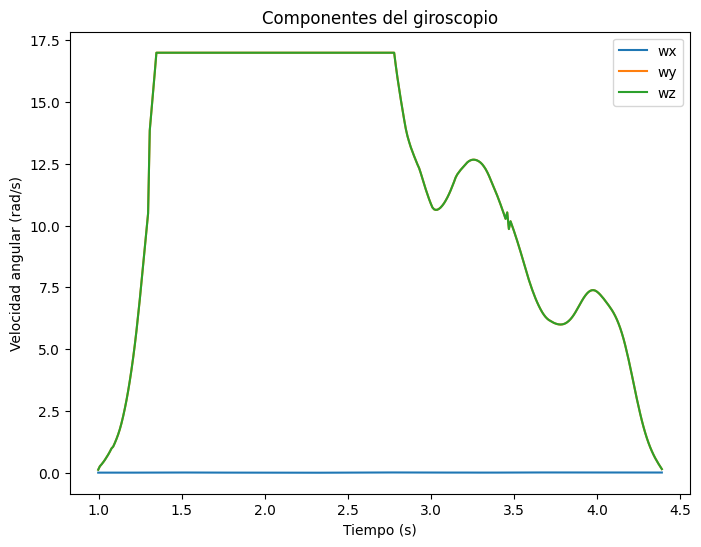

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

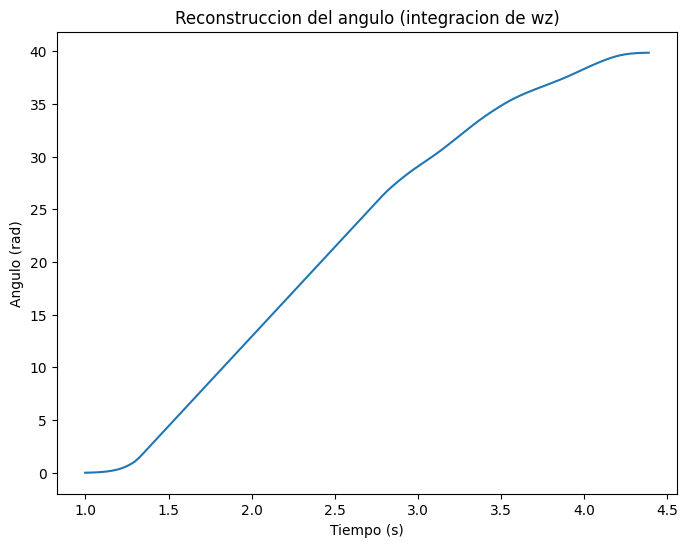

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

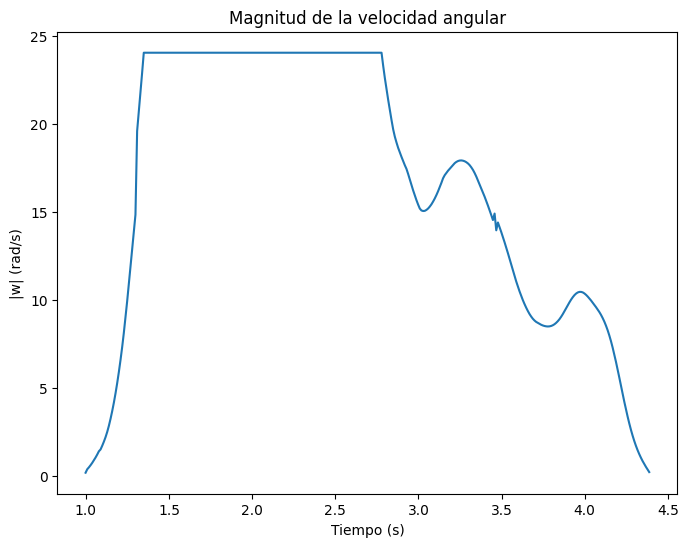

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

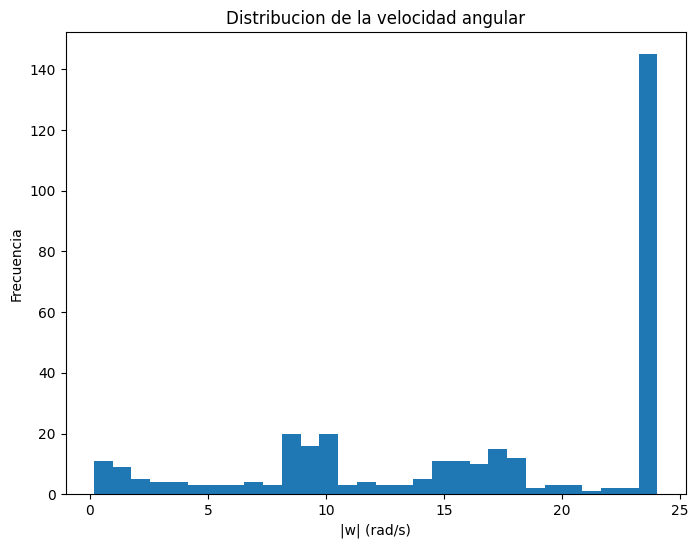

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# =====================================================
# LABORATORIO 2: GIROSCOPIO Y ORIENTACION
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# RUTA DE TRABAJO
# =====================================================

carpeta = "/content/drive/MyDrive/Proyecto_FisicaA/FisicaA/Data/"
archivo = "Lab4/Giroscopo.csv"

ruta = os.path.join(carpeta, archivo)

# =====================================================
# CREAR CARPETA SI NO EXISTE
# =====================================================

os.makedirs(carpeta, exist_ok=True)

# =====================================================
# LEER DATOS
# =====================================================

df = pd.read_csv(ruta)

# Filtramos para velocidad angular mayor a cero
mask = df["Gyroscope y (rad/s)"] > 0.1
df = df[mask]


t = df["Time (s)"].values
wx = df["Gyroscope x (rad/s)"].values
wy = df["Gyroscope y (rad/s)"].values
wz = df["Gyroscope y (rad/s)"].values

# =====================================================
# RECONSTRUCCION DEL ANGULO (EULER)
# =====================================================

theta = np.zeros_like(t)

for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    theta[i] = theta[i-1] + wz[i]*dt

# =====================================================
# MAGNITUD DE LA VELOCIDAD ANGULAR
# =====================================================

w_mag = np.sqrt(wx**2 + wy**2 + wz**2)

# =====================================================
# ANALISIS ESTADISTICO
# =====================================================

media = np.mean(w_mag)
varianza = np.var(w_mag)
desv = np.std(w_mag)

print("===== ANALISIS ESTADISTICO =====")
print(f"Media = {media:.4f}")
print(f"Varianza = {varianza:.4f}")
print(f"Desviacion estandar = {desv:.4f}")

# =====================================================
# GRAFICA 1: COMPONENTES DEL GIROSCOPIO
# =====================================================

plt.figure(figsize=(8,6))

plt.plot(t, wx, label="wx")
plt.plot(t, wy, label="wy")
plt.plot(t, wz, label="wz")

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Componentes del giroscopio")

plt.legend()

ruta_fig1 = os.path.join(carpeta, "Gyro_Componentes.pdf")
plt.savefig(ruta_fig1, dpi=300, bbox_inches="tight")
plt.show()

files.download(ruta_fig1)

# =====================================================
# GRAFICA 2: ANGULO RECONSTRUIDO
# =====================================================

plt.figure(figsize=(8,6))

plt.plot(t, theta)

plt.xlabel("Tiempo (s)")
plt.ylabel("Angulo (rad)")
plt.title("Reconstruccion del angulo (integracion de wz)")

ruta_fig2 = os.path.join(carpeta, "Gyro_Angulo.pdf")
plt.savefig(ruta_fig2, dpi=300, bbox_inches="tight")
plt.show()

files.download(ruta_fig2)

# =====================================================
# GRAFICA 3: MAGNITUD DE LA VELOCIDAD ANGULAR
# =====================================================

plt.figure(figsize=(8,6))

plt.plot(t, w_mag)

plt.xlabel("Tiempo (s)")
plt.ylabel("|w| (rad/s)")
plt.title("Magnitud de la velocidad angular")

ruta_fig3 = os.path.join(carpeta, "Gyro_Magnitud.pdf")
plt.savefig(ruta_fig3, dpi=300, bbox_inches="tight")
plt.show()

files.download(ruta_fig3)

# =====================================================
# GRAFICA 4: HISTOGRAMA
# =====================================================

plt.figure(figsize=(8,6))

plt.hist(w_mag, bins=30)

plt.xlabel("|w| (rad/s)")
plt.ylabel("Frecuencia")
plt.title("Distribucion de la velocidad angular")

ruta_fig4 = os.path.join(carpeta, "Gyro_Histograma.pdf")
plt.savefig(ruta_fig4, dpi=300, bbox_inches="tight")
plt.show()

files.download(ruta_fig4)

# =====================================================
# GUARDAR RESULTADOS ESTADISTICOS
# =====================================================

ruta_txt = os.path.join(carpeta, "Gyro_Estadistica.txt")

with open(ruta_txt, "w") as f:
    f.write("Resultados estadisticos\n")
    f.write(f"Media = {media}\n")
    f.write(f"Varianza = {varianza}\n")
    f.write(f"Desviacion = {desv}\n")

files.download(ruta_txt)